## Nous allons dans ce notebook créer des masques qui utilisent les outlines GLIMS pour superviser l'apprentissage de notre modèle. Nous voulons pouvoir utiliser ce masque qui représentera ce que nous voulons que le modèle prédise et qui aura deux classes, le Glacier pour tout ce qui se situe dans l'outline GLIMS et Autre pour tout ce qui n'est pas le glacier.

In [1]:
import geopandas as gpd
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
import re
from rasterio.features import rasterize
from pathlib import Path
from glacier.data import repo_root
root = repo_root()

# Reprenons le même glacier que dans le notebook de visualisation voici il a l'air de quoi

Showing: C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\data\sentinel2\composites\alps\G012104E47149N_2019_topk.tif


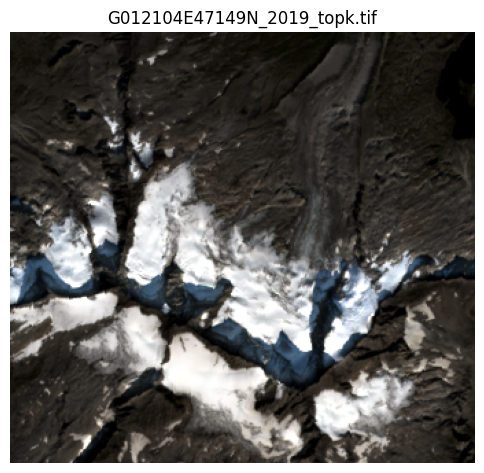

In [2]:
base = root / "data" / "sentinel2" / "composites" / "alps" # changer la région manuellement
glac_id = "G012104E47149N" 
year = 2019
p = base / f"{glac_id}_{year}_topk.tif"
print("Showing:", p)

da = rxr.open_rasterio(p).astype("float32")
img_crs = da.rio.crs  # on le réutilise après
# stretch simple (2-98 percentile) pour bien voir
def stretch(x):
    lo, hi = np.nanpercentile(x, 2), np.nanpercentile(x, 98)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1)

blue  = stretch(da[0].values)
green = stretch(da[1].values)
red   = stretch(da[2].values)

rgb = np.stack([red, green, blue], axis=-1)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.axis("off")
plt.title(p.name)
plt.show()

# Voici son contour GLIMS

glac_id: G012104E47149N


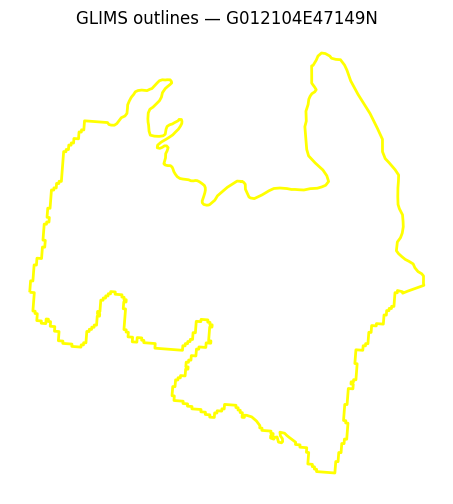

In [3]:
glac_id = p.stem.split("_")[0].strip()
print("glac_id:", glac_id)

glims = gpd.read_parquet(root / "data" / "processed" / "glims_satellite_ready.parquet")
glims["glac_id"] = glims["glac_id"].astype(str).str.strip()

if glims.crs is None:
    glims = glims.set_crs(4326)

g = glims[glims["glac_id"] == glac_id].copy()

if len(g) == 0:
    raise ValueError(f"Aucun outline GLIMS trouvé pour {glac_id}")

g = g.to_crs(img_crs)

fig, ax = plt.subplots(figsize=(6,6))
g.boundary.plot(ax=ax, color="yellow", linewidth=2)
ax.set_title(f"GLIMS outlines — {glac_id}")
ax.axis("off")
plt.show()

### On voit qu'il y a de nombreuses autres zones glacières dans le composite donc pour s'assurer de tous les prendre en compte on fera 

In [4]:
# MAX_GAP_YEARS on peut changer cette valeur pour voir l'effet sur
# le masque. Mettre None pour garder tous les outlines. de base on
# utilisait max 3 mais les performances du modèles etaient un peu bizarrre
# et on pense que c'est parce que certains des masques ne considéraient pas
#tous les glaciers sur l'image a cause de ceci

MAX_GAP_YEARS = None    # essayez 3, 5, 10, None

year_img = int(re.search(r"_(\d{4})_(summer|topk)$", p.stem).group(1))

minx, miny, maxx, maxy = da.rio.bounds()
patch_geom = box(minx, miny, maxx, maxy)

glims = gpd.read_parquet(root / "data" / "processed" / "glims_satellite_ready.parquet")
glims["glac_id"] = glims["glac_id"].astype(str).str.strip()

if glims.crs is None:
    glims = glims.set_crs(4326)

glims = glims.to_crs(img_crs)

inter = glims[glims.intersects(patch_geom)].copy()

inter["src_year"] = inter["src_date_dt"].dt.year
inter["gap"] = (inter["src_year"] - year_img).abs()
inter["best_gap"] = inter.groupby("glac_id")["gap"].transform("min")
inter = inter[inter["gap"] == inter["best_gap"]].copy()
inter_one = inter.dissolve(by="glac_id").reset_index()

if MAX_GAP_YEARS is not None:
    before = len(inter_one)
    inter_one = inter_one[inter_one["best_gap"] <= MAX_GAP_YEARS].copy()
    print(f"Filtre MAX_GAP_YEARS={MAX_GAP_YEARS} : {before} → {len(inter_one)} glaciers")
else:
    print(f"MAX_GAP_YEARS=None : on garde tous les {len(inter_one)} glaciers")

inter_one = inter_one.drop(columns=["gap", "best_gap"])

print(f"\nGlaciers in patch (unique): {inter_one['glac_id'].nunique()}")
print(f"Année image : {year_img}")

MAX_GAP_YEARS=None : on garde tous les 14 glaciers

Glaciers in patch (unique): 14
Année image : 2019


# Pour les glaciers avec plusieurs contours on peut voir son évolution avec le temps, puisque ça marche de manière générale (à quelques exceptions près), on garde uniquement le plus récent puisque c'est celui le plus adapté à l'état présent du glacier mais attention parfois on a pour un même ID plusieurs polygones et il faut pas tous les effacer, par exemple pour le glacier G012147E46958N cette cellule le montre bien 

             glac_id               src_date_dt  src_year  gap     area
3522  G012104E47149N 2016-08-27 00:00:00+00:00      2016    3  1.57089


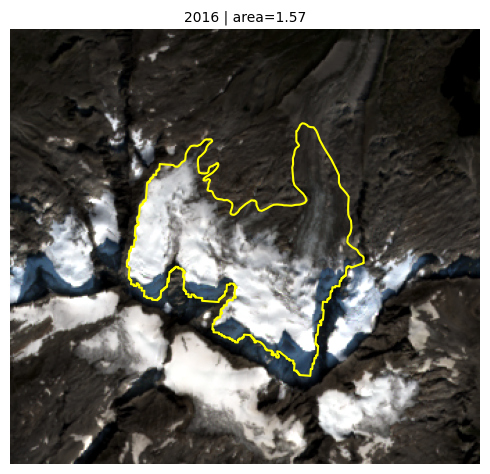

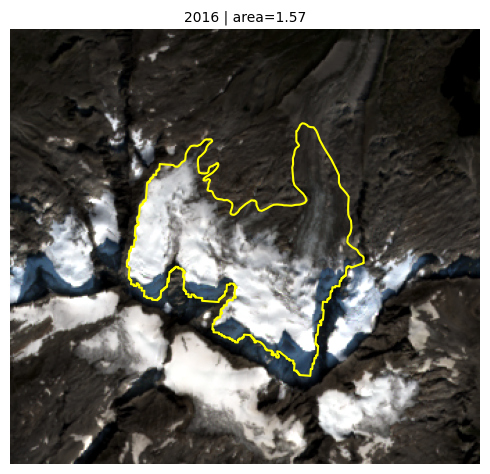

In [5]:
# Tous les outlines pour ce glacier dans le patch
this_glac = inter[inter["glac_id"] == glac_id].copy()
print(this_glac[["glac_id", "src_date_dt", "src_year", "gap", "area"]].to_string())

if len(this_glac) == 0:
    print(f"Aucun outline pour {glac_id} dans le patch")
else:
    fig, axes = plt.subplots(1, len(this_glac), figsize=(5 * len(this_glac), 5))
    if len(this_glac) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, this_glac.iterrows()):
        ax.imshow(rgb, extent=[minx, maxx, miny, maxy], origin="upper")
        gpd.GeoSeries([row.geometry]).boundary.plot(ax=ax, color="yellow", linewidth=1.5)
        ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
        ax.set_title(f"{row['src_year']} | area={row['area']:.2f}", fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, len(this_glac), figsize=(5 * len(this_glac), 5))
if len(this_glac) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, this_glac.iterrows()):
    ax.imshow(rgb, extent=[minx, maxx, miny, maxy], origin="upper")
    gpd.GeoSeries([row.geometry]).boundary.plot(ax=ax, color="yellow", linewidth=1.5)
    ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
    ax.set_title(f"{row['src_year']} | area={row['area']:.2f}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Voici l'image superposée par les outlines

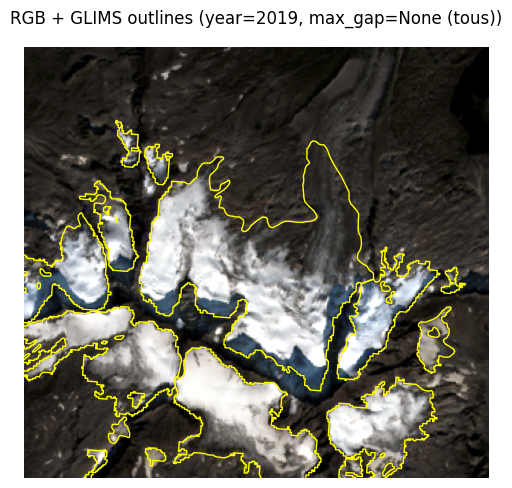

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# image géoréférencée
ax.imshow(rgb, extent=[minx, maxx, miny, maxy], origin="upper")

# contours GLIMS retenus
inter_one.boundary.plot(ax=ax, color="yellow", linewidth=1)

gap_str = f"max_gap={MAX_GAP_YEARS}" if MAX_GAP_YEARS is not None else "max_gap=None (tous)"
ax.set_title(f"RGB + GLIMS outlines (year={year_img}, {gap_str})")
ax.axis("off")
plt.show()

# Maintenant, le masque final, ce que nous voulons que le modèle apprenne à prédire !

In [7]:
transform = da.rio.transform()
H, W = da.rio.height, da.rio.width

inter_mask = inter_one.clip(patch_geom)

shapes = [
    (geom, 1)
    for geom in inter_mask.geometry
    if geom is not None and not geom.is_empty
]

mask = rasterize(
    shapes=shapes,
    out_shape=(H, W),
    transform=transform,
    fill=0,
    dtype="uint8",
)

print("Mask shape:", mask.shape)
print("Glacier pixels:", mask.sum())

Mask shape: (314, 339)
Glacier pixels: 38119


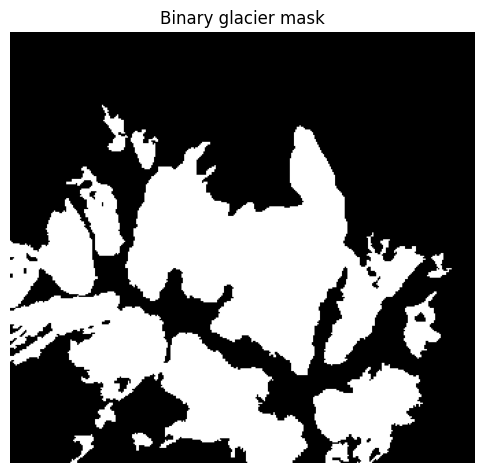

In [8]:
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.title("Binary glacier mask")
plt.axis("off")
plt.show()

# Tout semble bien fonctionner, on a alors réutiliseer cette logique pour faire la fonction glims_mask_for_composite que nous appliquerons à toutes nos données dans data_fetch_clean afin de créer le data set qui nous permettera de valider les prédictions faites par notre model.